## Bayesian Regularization

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

Consider the following simulated time series dataset. We first construct a smooth function on $[0, 1]$, then obtain data by adding normal noise to the true function. The underlying true function can be thought of as the true trend in this data that is obscured by noise. 

In [2]:
def smoothfun(x):
    ans = np.sin(15*x) + 3*np.exp(-(x ** 2)/2) + 0.5*((x - 0.5) ** 2) + 5 * np.log(x + 0.1) + 7
    return ans

n = 1000
xx = np.linspace(0, 1, n)
truth = np.array([smoothfun(x) for x in xx])

sig = 2
rng = np.random.default_rng(seed = 32)
errorsamples = rng.normal(loc=0, scale = sig, size = n)
y = truth + errorsamples

Here is a plot of the dataset along with the true trend function. 

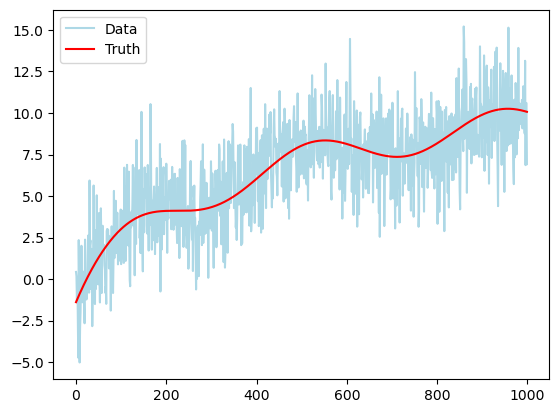

In [3]:
plt.plot(y, label = 'Data', color = 'lightblue')
plt.plot(truth, label = 'Truth', color = 'red')
plt.legend()
plt.show()

The goal is to estimate the trend function from the noisy data. We use the model:
\begin{align*}
   y_i = \theta_i + \epsilon_i
\end{align*}
where $\epsilon_i \overset{\text{i.i.d}}{\sim} N(0, \sigma^2)$, and $\theta_i$ denotes the true trend. We further write: 
\begin{align*}
   \theta_i = \beta_0 + \beta_1 (i-1) + \beta_2 (i - 2)_+ + \dots + \beta_{n-1} (i - (n-1))_+. 
\end{align*}
The model can also be written as: 
\begin{align*}
   y = X \beta + \epsilon
\end{align*}
where
\begin{equation*}
y = \begin{pmatrix}  y_1 \\ y_2 \\ y_3 \\ \cdot \\ \cdot \\ \cdot \\ y_n \end{pmatrix} \text{ and }
  X =
  \begin{pmatrix}
    1 & 0 & 0 & \cdot & \cdot & \cdot & 0 \\
    1 & 1 & 0 & \cdot & \cdot & \cdot & 0 \\
    1 & 2 & 1 & \cdot & \cdot & \cdot & 0 \\
    \cdot & \cdot & \cdot & \cdot & \cdot & \cdot & \cdot \\
    \cdot & \cdot & \cdot & \cdot & \cdot & \cdot & \cdot \\
    \cdot & \cdot & \cdot & \cdot & \cdot & \cdot & \cdot \\
    1 & n-1 & n-2 & \cdot & \cdot & \cdot & 1
  \end{pmatrix}
  \text{ and } \beta =
  \begin{pmatrix}
    \beta_0 \\ \beta_1 \\ \beta_2 \\ \cdot \\ \cdot \\ \cdot \\ \beta_{n-1}
  \end{pmatrix}. 
\end{equation*}



For the coefficients $\beta_j$, we use the following prior:
\begin{align*}
   \beta_0, \beta_1 \overset{\text{i.i.d}}{\sim} \text{unif}(-C, C) ~~~ \beta_2, \dots, \beta_{n-1} \overset{\text{i.i.d}}{\sim} N(0, \gamma^2 \sigma^2)
\end{align*}
We treat $\gamma$ and $\sigma$ also as unknown parameters and assign the prior: 
\begin{align*}
    \log \gamma, \log \sigma \overset{\text{i.i.d}}{\sim} \text{unif}(-C, C). 
\end{align*}
This is the same as the prior that we used in Lecture 20 (this problem can be thought of as regression with $x_i = i$). The posterior of $\gamma, \sigma, \beta$ can be described as follows. 


The posterior of $\beta$ conditional on $\sigma$ and $\gamma$ is given by: 
\begin{align*}
   \beta \mid \text{data}, \sigma, \tau \sim N \left(\left(\frac{X^T
                          X}{\sigma^2} + Q^{-1}  \right)^{-1} \frac{X^T y}{\sigma^2},  \left(\frac{X^T X}{\sigma^2} + Q^{-1} \right)^{-1}\right). 
\end{align*}
where $Q$ is the diagonal matrix with diagonal entries $C, C, \gamma^2\sigma^2, \dots, \gamma^2\sigma^2$. This is the same as before. We shall again use the approximation $Q^{-1} \approx J/\tau^2 = J/(\gamma \sigma)^2$. 

The posterior of $\sigma$ conditional on $\gamma$ can be described in closed form as: 

 \begin{equation*}
   \frac{1}{\sigma^2} \mid \text{data}, \gamma \sim \text{Gamma} \left(\frac{n}{2} - 1, \frac{y^T y - y^T X (X^T X + \gamma^{-2} J)^{-1} X^T y}{2} \right) 
 \end{equation*}
 Finally the posterior of $\gamma$ is given by: 

 \begin{align*}
   \gamma \mid \text{data} \sim \gamma^{-n+1} \sqrt{\det (X^T X + \gamma^{-2} J)^{-1}} \left(\frac{1}{y^T y - y^T X (X^T X + \gamma^{-2} J)^{-1} X^T y} \right)^{(n/2) - 1}
 \end{align*}
 We can compute this posterior on a grid of $\gamma$ values.

In [4]:
n = len(y)
x = np.arange(1, n+1)
X = np.column_stack([np.ones(n), x-1])
for i in range(n-2):
    c = i+2
    xc = ((x > c).astype(float))*(x-c)
    X = np.column_stack([X, xc])
print(X)

[[  1.   0.  -0. ...  -0.  -0.  -0.]
 [  1.   1.   0. ...  -0.  -0.  -0.]
 [  1.   2.   1. ...  -0.  -0.  -0.]
 ...
 [  1. 997. 996. ...   1.   0.  -0.]
 [  1. 998. 997. ...   2.   1.   0.]
 [  1. 999. 998. ...   3.   2.   1.]]


To select the grid range for $\gamma$, we can use the following method. For a fixed $\gamma$, note that the ridge regularized estimate of $\beta$ with tuning parameter $\lambda = 1/\gamma^2$ is given by $(X^T X + \lambda J)^{-1}X^Ty$. We choose $\lambda_{\min}$ to be such that the fitted values corresponding to the ridge estimator look like the data (overfitting) and $\lambda_{\max}$ to be such that the fitted values are close to being a line. The range for $\gamma$ is then $[1/\sqrt{\lambda_{\max}}, 1/\sqrt{\lambda_{\min}}]$.  

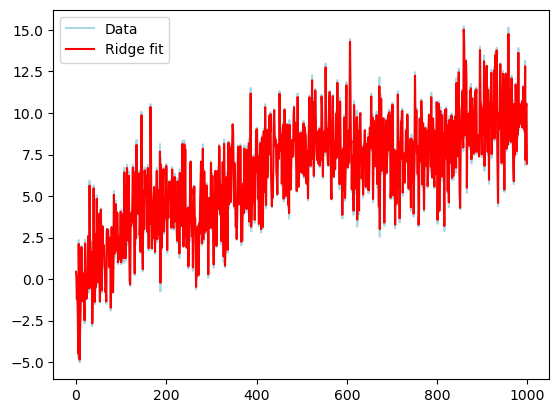

In [5]:
lambda_ridge = 1e-2
J = np.diag(np.array([0] + [0] + [1]*(n-2)))
ridge_beta = np.linalg.inv(X.T @ X + lambda_ridge * J) @ X.T @ y
ridge_fitted = X @ ridge_beta
plt.plot(y, label = 'Data', color = 'lightblue')
plt.plot(ridge_fitted, label = 'Ridge fit', color = 'red')
plt.legend()
plt.show()
#this plot suggests:
lambda_min = 1e-2

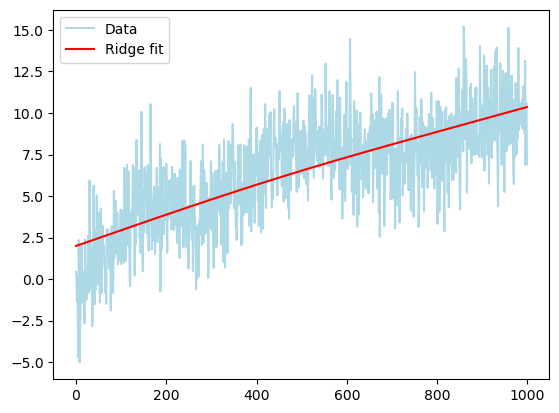

In [6]:
lambda_ridge = 1e10
J = np.diag(np.array([0] + [0] + [1]*(n-2)))
ridge_beta = np.linalg.inv(X.T @ X + lambda_ridge * J) @ X.T @ y
ridge_fitted = X @ ridge_beta
plt.plot(y, label = 'Data', color = 'lightblue')
plt.plot(ridge_fitted, label = 'Ridge fit', color = 'red')
plt.legend()
plt.show()
#this plot suggests:
lambda_max = 1e10

In [7]:
gamma_min = 1/np.sqrt(lambda_max)
gamma_max = 1/np.sqrt(lambda_min)
print(gamma_min, gamma_max)

1e-05 10.0


We take a grid of $\gamma$ in the range given by the minimum and maximum values above. The grid will be chosen uniformly over the log-scale. 

In [8]:
gamma_gr = np.logspace(np.log10(gamma_min), np.log10(gamma_max), 1000)
logpost_gamma = np.zeros(len(gamma_gr))

for i in range(len(gamma_gr)):
    gamma = gamma_gr[i]
    J_by_gammasq = np.diag(np.concatenate([[0, 0], np.repeat(gamma**(-2), n-2)])) 
    Mat =  X.T @ X + J_by_gammasq
    Matinv = np.linalg.inv(Mat)
    sgn, logcovdet = np.linalg.slogdet(Matinv)
    logpost_gamma[i] =(-n+1)*np.log(gamma) + 0.5 * logcovdet - (n/2 - 1)*np.log(y.T @ y - y.T @ X @ Matinv @ X.T @ y)
    if i % 100 == 0:
        print(i)


0
100
200
300
400
500
600
700
800
900


In [9]:
post_gamma  = np.exp(logpost_gamma - np.max(logpost_gamma))
post_gamma = post_gamma/np.sum(post_gamma)

For a point estimate of $\gamma$, we can compute the posterior mean as follows. 

In [10]:
postmean_gamma = np.sum(gamma_gr * post_gamma)
print(postmean_gamma)
print(1/(postmean_gamma ** 2))

0.001010381749167623
979555.4253711331


Posterior samples from $\gamma$ can be generated as follows. 

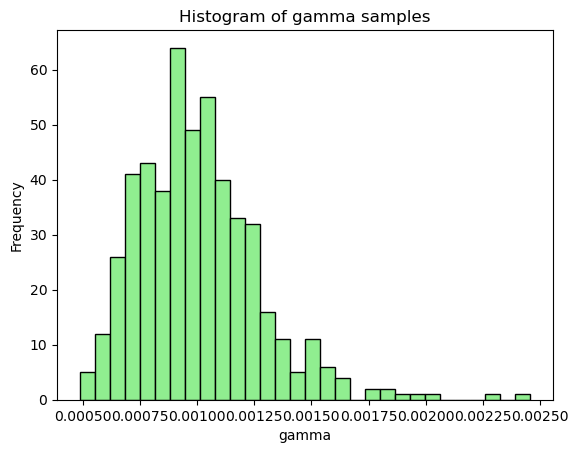

In [11]:
N = 500
gamma_samples = np.random.choice(gamma_gr, size=N, p=post_gamma, replace=True)
plt.hist(gamma_samples, bins=30, color='lightgreen', edgecolor='black')
plt.title('Histogram of gamma samples')
plt.xlabel('gamma')
plt.ylabel('Frequency')
plt.show()

Here is the code for generating the samples from the other parameters $\sigma$ and $\beta$. 

In [12]:
N = 500
sig_samples = np.array(np.zeros(N))
betahats = np.zeros((n, N))
muhats = np.zeros((n, N))

for i in range(N):
    gamma = gamma_samples[i]
    J_by_gammasq = np.diag(np.concatenate([[0, 0], np.repeat(gamma**(-2), n-2)])) 
    Mat =  X.T @ X + J_by_gammasq
    Matinv = np.linalg.inv(Mat)
    gamma_dist_lambda_parameter = (y.T @ y - y.T @ X @ Matinv @ X.T @ y)/2
    gamma_dist_alpha_parameter = n/2 - 1
    sig = np.sqrt(1/np.random.gamma(gamma_dist_alpha_parameter, 1/gamma_dist_lambda_parameter))
    sig_samples[i] = sig
    XTX = np.dot(X.T, X)
    TempMat = np.linalg.inv((J_by_gammasq/(sig ** 2)) + (XTX/(sig ** 2)))
    XTy = np.dot(X.T, y)
    #generate betahat from the normal distribution with mean: 
    norm_mean = np.dot(TempMat, XTy/(sig ** 2)) 
    #and covariance matrix: 
    norm_cov = TempMat  
    betahat = np.random.multivariate_normal(norm_mean, norm_cov)
    muhat = np.dot(X, betahat)
    betahats[:,i] = betahat
    muhats[:,i] = muhat
    if i % 100 == 0:
        print(i)
    

0
100
200
300
400


Below we compute and plot the posterior means for $\beta$ and $X \beta$. 

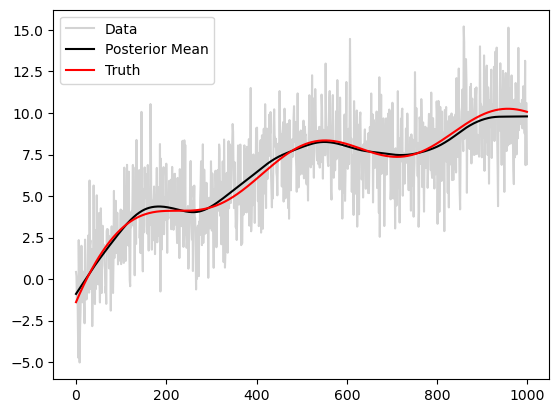

In [13]:
beta_est = np.mean(betahats, axis = 1)
mu_est = np.mean(muhats, axis = 1) #these are the fitted values

plt.plot(y, label = 'Data', color = 'lightgray')
plt.plot(mu_est, color = 'black', label = 'Posterior Mean')
plt.plot(truth, color = 'red', label = 'Truth')
plt.legend()
plt.show()


The estimate is quite close to the true function. 

Below we plot the individual posterior samples for $X\beta$. These can be used for uncertainty quantification. 

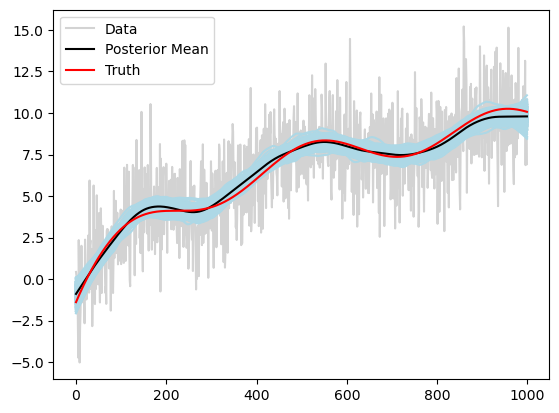

In [14]:
#Plotting all the posterior fitted values
plt.plot(y, label = 'Data', color = 'lightgray')
for i in range(N):
    plt.plot(muhats[:,i], color = 'lightblue')
plt.plot(mu_est, color = 'black', label = 'Posterior Mean')
plt.plot(truth, color = 'red', label = 'Truth')
plt.legend()
plt.show()


The true smooth function (which generated the data) is inside the bands given by the individual posterior samples of $X\beta$. 

Here is the histogram of the $\sigma$ values. 

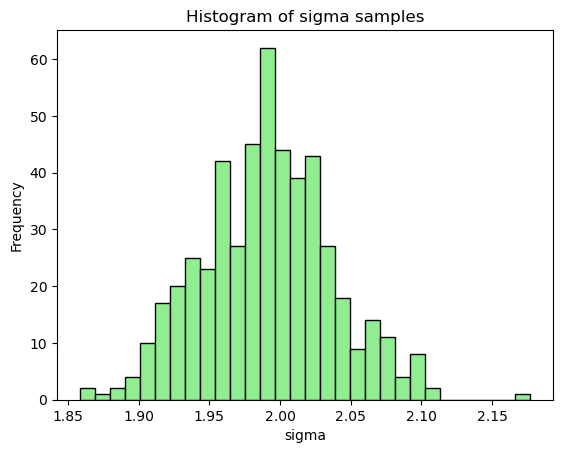

In [15]:
plt.hist(sig_samples, bins=30, color='lightgreen', edgecolor='black')
plt.title('Histogram of sigma samples')
plt.xlabel('sigma')
plt.ylabel('Frequency')
plt.show()

Note that the true $\sigma$ which generated the data is 2. 

## One More Example

We now consider one more example where the data is generated from a true trend function that is piecewise linear. In this case, this method works still well but struggles to find the sharp change of slope points. Instead, it ends up smoothing those kink points.

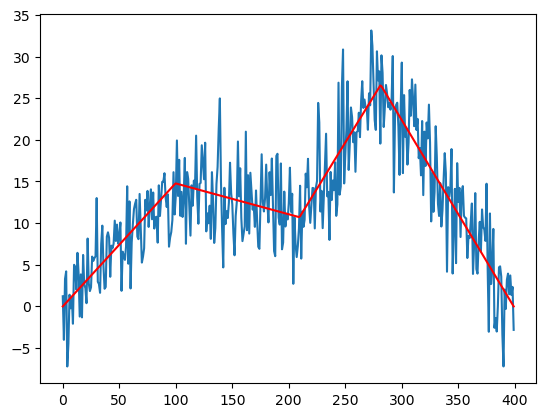

In [16]:
def piece_linear(x):
    ans = np.zeros_like(x, dtype=float)
    
    # First segment: 0 <= x <= 0.25
    mask1 = (x >= 0) & (x <= 0.25)
    ans[mask1] = (14.77491 / 0.25) * x[mask1]
    
    # Second segment: 0.25 < x <= 0.525
    mask2 = (x > 0.25) & (x <= 0.525)
    ans[mask2] = (10.71181 + ((10.71181 - 14.77491) / (0.525 - 0.25)) * (x[mask2] - 0.525))
    
    # Third segment: 0.525 < x <= 0.705
    mask3 = (x > 0.525) & (x <= 0.705)
    ans[mask3] = (26.59484 + ((26.59584 - 10.71181) / (0.705 - 0.525)) * (x[mask3] - 0.705))
    
    # Fourth segment: 0.705 < x <= 1
    mask4 = (x > 0.705) & (x <= 1)
    ans[mask4] = ((0 - 26.59584) / (1 - 0.705)) * (x[mask4] - 1)
    
    return ans

n = 400
xx = np.linspace(0, 1, 400)
truth = piece_linear(xx)

sig = 4
rng = np.random.default_rng(seed = 42)
errorsamples = rng.normal(loc=0, scale = sig, size = n)
y = truth + errorsamples
plt.plot(y, label = 'Data')
plt.plot(truth, label = 'Truth', color = 'red')
plt.show()

In [17]:
n = len(y)
x = np.arange(1, n+1)
X = np.column_stack([np.ones(n), x-1])
for i in range(n-2):
    c = i+2
    xc = ((x > c).astype(float))*(x-c)
    X = np.column_stack([X, xc])
print(X)

[[  1.   0.  -0. ...  -0.  -0.  -0.]
 [  1.   1.   0. ...  -0.  -0.  -0.]
 [  1.   2.   1. ...  -0.  -0.  -0.]
 ...
 [  1. 397. 396. ...   1.   0.  -0.]
 [  1. 398. 397. ...   2.   1.   0.]
 [  1. 399. 398. ...   3.   2.   1.]]


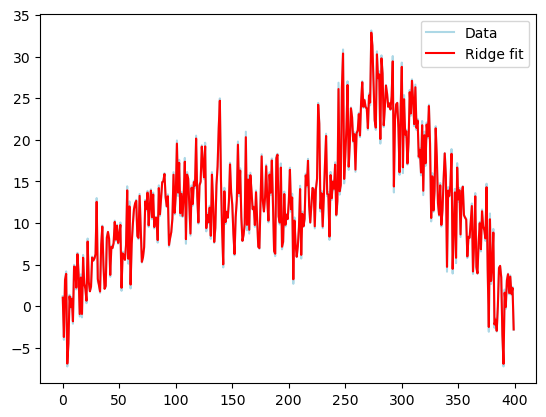

In [18]:
lambda_ridge = 1e-2
ridge_beta = np.linalg.inv(X.T @ X + lambda_ridge * np.eye(n)) @ X.T @ y
ridge_fitted = X @ ridge_beta
plt.plot(y, label = 'Data', color = 'lightblue')
plt.plot(ridge_fitted, label = 'Ridge fit', color = 'red')
plt.legend()
plt.show()
#this plot suggests:
lambda_min = 1e-2

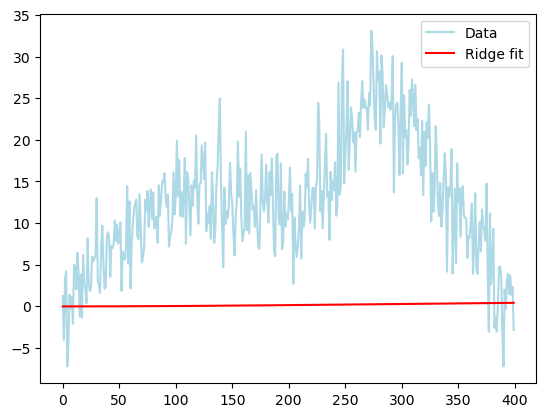

In [19]:
lambda_ridge = 1e11
ridge_beta = np.linalg.inv(X.T @ X + lambda_ridge * np.eye(n)) @ X.T @ y
ridge_fitted = X @ ridge_beta
plt.plot(y, label = 'Data', color = 'lightblue')
plt.plot(ridge_fitted, label = 'Ridge fit', color = 'red')
plt.legend()
plt.show()
#this plot suggests:
lambda_max = 1e11

In [20]:
gamma_min = 1/np.sqrt(lambda_max)
gamma_max = 1/np.sqrt(lambda_min)
print(gamma_min, gamma_max)

3.1622776601683796e-06 10.0


In [21]:
gamma_gr = np.logspace(np.log10(gamma_min), np.log10(gamma_max), 1000)
logpost_gamma = np.zeros(len(gamma_gr))

for i in range(len(gamma_gr)):
    gamma = gamma_gr[i]
    J_by_gammasq = np.diag(np.concatenate([[0, 0], np.repeat(gamma**(-2), n-2)])) 
    Mat =  X.T @ X + J_by_gammasq
    Matinv = np.linalg.inv(Mat)
    sgn, logcovdet = np.linalg.slogdet(Matinv)
    logpost_gamma[i] =(-n+1)*np.log(gamma) + 0.5 * logcovdet - (n/2 - 1)*np.log(y.T @ y - y.T @ X @ Matinv @ X.T @ y)
    if i % 100 == 0:
        print(i)


0
100
200
300
400
500
600
700
800
900


In [22]:
post_gamma  = np.exp(logpost_gamma - np.max(logpost_gamma))
post_gamma = post_gamma/np.sum(post_gamma)

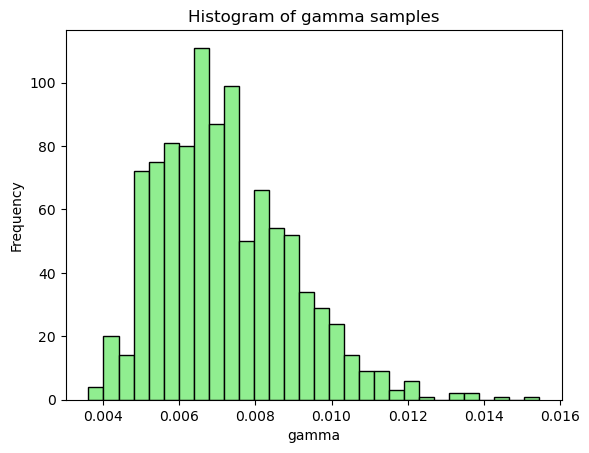

In [23]:
N = 1000
gamma_samples = np.random.choice(gamma_gr, size=N, p=post_gamma, replace=True)
plt.hist(gamma_samples, bins=30, color='lightgreen', edgecolor='black')
plt.title('Histogram of gamma samples')
plt.xlabel('gamma')
plt.ylabel('Frequency')
plt.show()

In [24]:
N = 1000
sig_samples = np.array(np.zeros(N))
betahats = np.zeros((n, N))
muhats = np.zeros((n, N))

for i in range(N):
    gamma = gamma_samples[i]
    J_by_gammasq = np.diag(np.concatenate([[0, 0], np.repeat(gamma**(-2), n-2)])) 
    Mat =  X.T @ X + J_by_gammasq
    Matinv = np.linalg.inv(Mat)
    gamma_dist_lambda_parameter = (y.T @ y - y.T @ X @ Matinv @ X.T @ y)/2
    gamma_dist_alpha_parameter = n/2 - 1
    sig = np.sqrt(1/np.random.gamma(gamma_dist_alpha_parameter, 1/gamma_dist_lambda_parameter))
    sig_samples[i] = sig
    XTX = np.dot(X.T, X)
    TempMat = np.linalg.inv((J_by_gammasq/(sig ** 2)) + (XTX/(sig ** 2)))
    XTy = np.dot(X.T, y)
    #generate betahat from the normal distribution with mean: 
    norm_mean = np.dot(TempMat, XTy/(sig ** 2)) 
    #and covariance matrix: 
    norm_cov = TempMat  
    betahat = np.random.multivariate_normal(norm_mean, norm_cov)
    muhat = np.dot(X, betahat)
    betahats[:,i] = betahat
    muhats[:,i] = muhat
    if i % 100 == 0:
        print(i)
    

0
100
200
300
400
500
600
700
800
900


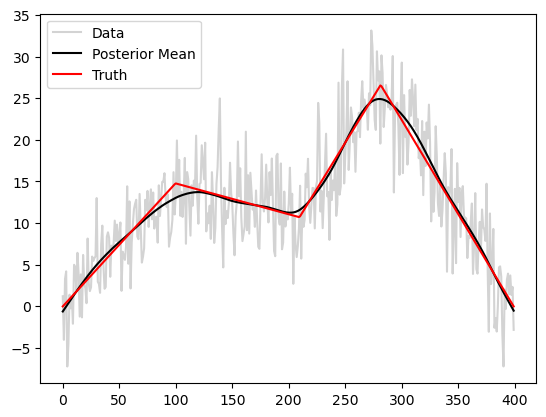

In [25]:
beta_est = np.mean(betahats, axis = 1)
mu_est = np.mean(muhats, axis = 1) #these are the fitted values

plt.plot(y, label = 'Data', color = 'lightgray')
plt.plot(mu_est, color = 'black', label = 'Posterior Mean')
plt.plot(truth, color = 'red', label = 'Truth')
plt.legend()
plt.show()


See how the sharp kink points are smoothed in the estimate given by the Bayesian method. 

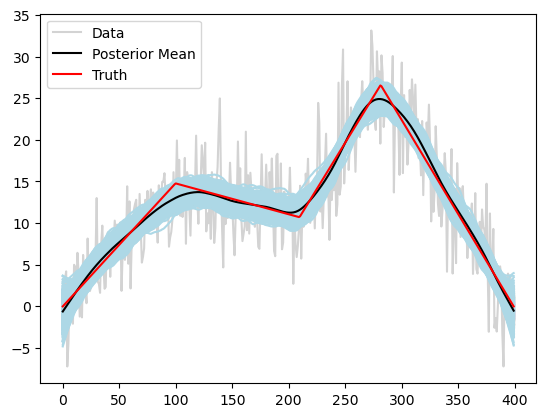

In [26]:
#Plotting all the posterior fitted values
plt.plot(y, label = 'Data', color = 'lightgray')
for i in range(N):
    plt.plot(muhats[:,i], color = 'lightblue')
plt.plot(mu_est, color = 'black', label = 'Posterior Mean')
plt.plot(truth, color = 'red', label = 'Truth')
plt.legend()
plt.show()


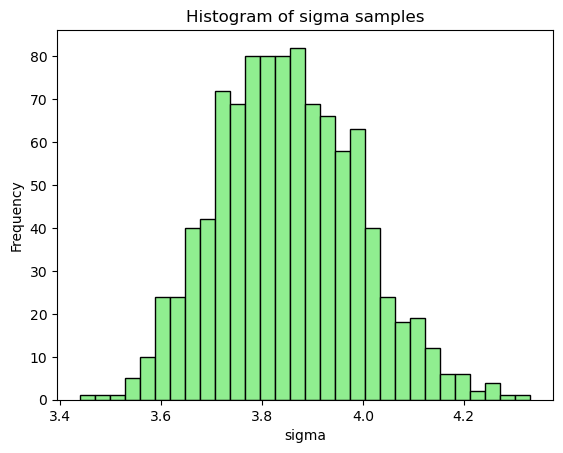

In [27]:
plt.hist(sig_samples, bins=30, color='lightgreen', edgecolor='black')
plt.title('Histogram of sigma samples')
plt.xlabel('sigma')
plt.ylabel('Frequency')
plt.show()

Note that the true $\sigma$ value is 4.